# CNMFe pipeline — part 2: extract neuronal components

Picks up where **`01_load_and_motion_correct.ipynb`** left off: the motion-
corrected zarr (`mc.zarr`) is on disk. This notebook runs the rest of the
CNMFe pipeline:

1. **Load** the motion-corrected movie into RAM *or* go straight to the
   streaming path. Spatial / temporal updates need pixel-major access, so
   either the movie is materialised once as `(T, H, W)` float32, *or*
   `fit()` runs against a pixel-major zarr on disk (auto-derived from
   `output_dir`). The streaming path is now genuinely parallel — the ring
   solve uses threaded workers that release the GIL.
2. **CORR / PNR diagnostic** — visualise where the neurons are *before*
   running extraction. Lets you pick `sigma`, `min_corr`, `min_pnr` from
   the data instead of guessing.
3. **Configure** `CNMFeParams` (with `n_jobs=-1` for parallel extraction)
   and run `CNMFe.fit(...)`. The pipeline prints a config line at the
   start (`Extraction config: n_jobs=X device=Y T=A H=B W=C streaming=...`)
   so you can see at a glance whether parallelism and streaming are on.
   Internally: greedy CORR/PNR init (on a strided sample — see
   `init_stride`) → ring-model background → spatial LASSO → temporal
   OASIS deconvolution → merge duplicates, iterated `n_iter_main` times
   → auto-evaluation (footprint pixel count + amplitude-SNR filter).
4. **Inspect results** — footprints overlaid on the mean image, a few
   traces (`C`, `C + YrA` via `model.C_projected`, `S`).
5. **Save** with `model.save(output_dir)`. Reload anywhere with
   `CNMFe.load(output_dir)`.

The file layout `save()` writes matches `full_pipeline.py`, so downstream
analysis scripts work either way.

**For very long recordings (60k+ frames)** the in-RAM load doesn't scale.
**Section 9** at the bottom shows the streaming path: pass `output_dir=` to
`fit()` and the pixel-major store is auto-built; peak RAM stays bounded by
`K·T·4` regardless of T.

## 1. Imports & paths

Point `MC_ZARR` at the `mc.zarr` produced by part 1 (or any motion-corrected
zarr â€” the extraction step doesn't care how it was produced).

In [1]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp

from minicnmfe.io import open_zarr
from minicnmfe.pipeline import CNMFe, CNMFeParams
from minicnmfe.preprocess import correlation_pnr

# Path to the motion-corrected zarr produced by part 1.
PROJECT_ROOT = Path('/home/fs539/code/simpler_cnmfe')
MC_ZARR  = PROJECT_ROOT / 'demo_movies' / 'demo_session' / 'mc_output' / 'mc.zarr'
OUTPUT_DIR = MC_ZARR.parent / 'results'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'mc zarr     : {MC_ZARR}')
print(f'results dir : {OUTPUT_DIR}')

mc zarr     : /home/fs539/code/simpler_cnmfe/demo_movies/demo_session/mc_output/mc.zarr
results dir : /home/fs539/code/simpler_cnmfe/demo_movies/demo_session/mc_output/results


## 2. Load the corrected movie into RAM

The extraction steps need pixel-major access to every frame, so the movie
is materialised once as `(T, H, W)` float32. Peak working RAM during
extraction is roughly **just this array plus small per-batch buffers** â€”
`BackgroundSubtractor` is lazy (slices of `(I-W)Â·(Y-b0)` on demand) and
`compute_W` caches the ring weight matrix across BCD iterations, so the
per-step overhead is bounded by `KÂ·TÂ·4` bytes plus a small pixel-batch
slice.

**Rule of thumb:** the dominant cost is the loaded movie itself,
`T * H * W * 4` bytes. A 10k-frame 600Ã—600 movie is ~14 GB. 60k frames at
the same dims is ~86 GB â€” switch to the **streaming workflow in
Section 9** rather than subsampling.

In [2]:
mc_zarr = open_zarr(MC_ZARR)
T_full, H, W = mc_zarr.shape
ram_gb = T_full * H * W * 4 / 1e9

print(f'mc.zarr shape : {mc_zarr.shape}')
print(f'        chunks: {mc_zarr.chunks}')
print(f'        dtype : {mc_zarr.dtype}')
print(f'estimated RAM for full load (float32): {ram_gb:.1f} GB')

mc.zarr shape : (11000, 600, 600)
        chunks: (200, 600, 600)
        dtype : float32
estimated RAM for full load (float32): 15.8 GB


In [14]:
# --- Optional time subsampling of the materialised movie ---------------------
# Controls the `(T, H, W)` float32 array we load into RAM. Extraction never
# holds more than one copy of this plus small per-batch buffers (Phase A+B
# refactors: BackgroundSubtractor is lazy, compute_W avoids the full
# residual). So at 600x600 the rule of thumb is T * H * W * 4 bytes â€” 14 GB
# at 10k frames, 86 GB at 60k.
#
# If your movie won't fit in RAM:
#  - Moderate (slight RAM pressure):  set TIME_STRIDE > 1 here. This
#    subsamples *everything* downstream (footprints, traces, mean image).
#  - Huge (60k+ frames): skip this cell and use the streaming workflow in
#    Section 9 below. `fit(..., Y_flat_zarr=...)` runs against an on-disk
#    pixel-major zarr; peak RAM is bounded by KÂ·TÂ·4 regardless of T.
#
# A more targeted knob lives on CNMFeParams: `init_stride`. That subsamples
# *only* the greedy CORR/PNR init step (which transiently allocates two
# more copies of the movie), leaving the rest of the pipeline at full T.
# `init_stride=None` (default) auto-selects max(1, T // 5000). Tune it in
# the params cell below if you want to be explicit.
TIME_STRIDE = 1

t0 = time.time()
if TIME_STRIDE > 1:
    movie = np.asarray(mc_zarr[::TIME_STRIDE], dtype=np.float32)
else:
    movie = np.asarray(mc_zarr, dtype=np.float32)

movie = movie[:5000]
T = movie.shape[0]
print(f'loaded movie : shape={movie.shape}  dtype={movie.dtype}')
print(f'              ~{movie.nbytes / 1e9:.2f} GB in RAM   (load took {time.time()-t0:.1f}s)')

loaded movie : shape=(5000, 600, 600)  dtype=float32
              ~7.20 GB in RAM   (load took 17.1s)


## 3. CORR / PNR diagnostic â€” find where the neurons are

Two summary images tell you where neurons live and let you set extraction
thresholds from data rather than guessing:

- **CORR** â€” at each pixel, the mean Pearson correlation with its 8
  neighbours over time. A neuron spans several pixels that all flash
  together â†’ CORR is high inside the neuron.
- **PNR** (peak-to-noise ratio) â€” max Î”F / noise std at each pixel. Bright
  transients â†’ high PNR.

Their product `CORR Ã— PNR` is the seed score used by greedy init:
noisy-looking pixels with chance correlation get filtered out (low PNR),
bright artefacts get filtered out (low CORR).

A **center-surround PSF** (DoG-like, sums to zero) is applied before computing
CORR/PNR â€” this suppresses the diffuse 1p background and isolates structures
at the neuron scale defined by `sigma`. Set `center_psf=False` for 2p data.

**Pick `sigma`** â‰ˆ the neuron *radius* in pixels. Eyeball a few neurons in
the mean image first.

In [15]:
# Sigma in pixels â€” the neuron radius. Adjust to match your data.
SIGMA = 5.0

# correlation_pnr already strides internally if the movie is long; we just pass
# the full (possibly subsampled) movie.
t0 = time.time()
cn, pnr = correlation_pnr(movie, sigma=SIGMA, center_psf=True, n_jobs=-1, stride = 10)
print(f'CORR/PNR computed in {time.time()-t0:.1f}s')
print(f'  CORR range: [{cn.min():.3f}, {cn.max():.3f}]')
print(f'  PNR  range: [{pnr.min():.3f}, {pnr.max():.3f}]')

CORR/PNR computed in 13.7s
  CORR range: [-0.004, 1.000]
  PNR  range: [1.895, 42.876]


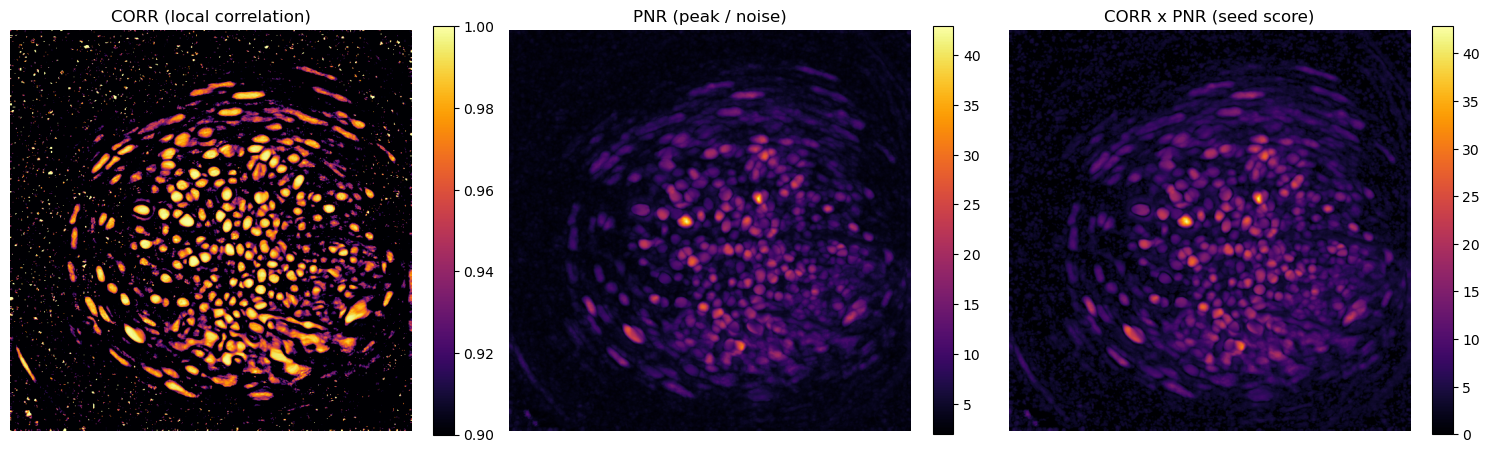

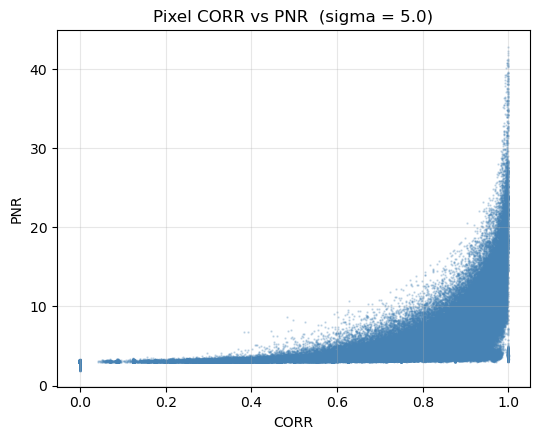

Pick `min_corr` and `min_pnr` to sit just below the visible cluster of bright pixels.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
im0 = axes[0].imshow(cn, cmap='inferno', vmin=0.9, vmax=1)
axes[0].set_title('CORR (local correlation)')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(pnr, cmap='inferno')
axes[1].set_title('PNR (peak / noise)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(cn * pnr, cmap='inferno')
axes[2].set_title('CORR x PNR (seed score)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)
plt.tight_layout()
plt.show()

# Pixel scatter to help pick thresholds.
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(cn.ravel(), pnr.ravel(), s=0.5, alpha=0.25, c='steelblue')
ax.set_xlabel('CORR')
ax.set_ylabel('PNR')
ax.set_title(f'Pixel CORR vs PNR  (sigma = {SIGMA})')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('Pick `min_corr` and `min_pnr` to sit just below the visible cluster of bright pixels.')

## 4. Configure extraction parameters

All algorithm parameters live on `CNMFeParams`. The most-tuned ones for new
data:

| Param | Meaning | Typical |
|---|---|---|
| `sigma` | Neuron radius in pixels | 2â€“5 |
| `min_corr` | Min CORR for a seed | 0.6â€“0.9 |
| `min_pnr` | Min PNR for a seed | 5â€“15 |
| `max_neurons` | Stop greedy init after N (None = no cap) | None |
| `init_stride` | Greedy-init temporal stride; `None` auto = `max(1, T // 5000)` | None |
| `init_corrpnr_stride` | Extra stride applied to the *initial* CORR/PNR sweep; `None` auto = `max(1, T_init // 2000)` | None |
| `n_iter_main` | Spatial + temporal + merge cycles | 1â€“3 |
| `n_iter_temporal` | BCD passes inside each temporal update | 2 |
| `merge_thr_corr` | Min temporal r to merge two components | 0.85 |
| `merge_thr_overlap` | Min Jaccard footprint overlap to merge | 0.5 |
| `merge_centre_dist_factor` | Centre-distance fallback (Ã— sigma) | 2.0 |
| `spatial_max_thr` | Footprint cleanup threshold (fraction of peak) | 0.1 |
| `min_pixel` | Auto-eval hard pixel-count floor per component | 3 |
| `auto_eval_snr_amp_thr` | Auto-eval mean-amplitude SNR threshold; `0` to disable | 3.0 |
| `global_ar` | `True` = one g for all neurons; `False` = per-neuron | `True` |
| `n_jobs` | CPU workers; `-1` = all cores | `-1` |

Init has two independent strides. `init_stride` controls the `(T, H, W)`
sample passed to greedy init (caps the data_filtered / data_raw RAM cost).
`init_corrpnr_stride` further subsamples time **just inside the initial
CORR/PNR sweep** â€” those reductions only need a representative slice of
frames, so a strided view gives a near-identical seed map at a fraction
of the cost. The greedy loop's local CORR/PNR updates after each
detection still run on the full strided patch.

Auto-evaluation runs between the BCD loop and the final temporal pass â€”
see `minicnmfe.evaluate.auto_evaluate_components`. A component must pass two
checks: a hard pixel-count floor (`min_pixel`) and a scale-invariant
mean-amplitude SNR check (`mean(aÂ²) / mean(snÂ²) >= auto_eval_snr_amp_thr`)
that catches ghost components whose footprint sits at the pixel-noise
floor. Set `auto_eval_snr_amp_thr=0` to disable the SNR check.

Start with the values below â€” they're sane defaults for 1p miniscope data â€”
then refine after looking at extracted footprints and traces.

In [24]:
params = CNMFeParams(
    # Detection
    sigma=SIGMA,
    min_corr=0.9,
    min_pnr=15.0,
    max_neurons=None,

    # Main refinement loop
    n_iter_main=2,
    n_iter_temporal=2,

    # Merging
    merge_thr_corr=0.85,
    merge_thr_overlap=0.5,
    merge_centre_dist_factor=2.0,

    # Spatial cleanup
    spatial_max_thr=0.1,

    # Temporal
    ar_order=1,
    global_ar=True,
    skip_first_deconv=True,        # NNLS on the first pass, OASIS afterwards
    # Bayesian prior on g (preferred over fudge_factor when known).
    # Set both `decay_time_ms` and `frame_rate_hz` to enable.
    # Single-AP τ_decay (ms), somatic, approximate:
    #   GCaMP6f ~140   jGCaMP7f ~160
    #   jGCaMP8f ~70   jGCaMP8m ~180   jGCaMP8s ~350
    #   GCaMP6s/7s ~1000
    # `g_prior_weight` ∈ [0, 1]: 0 = pure Yule-Walker, 1 = pin at target.
    # 0.5 is a balanced default; bump toward 1 on drift-heavy recordings
    # (the Yule-Walker estimate is upward-biased there).
    decay_time_ms=180,
    frame_rate_hz=20,
    g_prior_weight=1,
    # A/B vs todo/oasis_oversmoothing.md — un-pin g from the 0.96 ceiling
    # (Yule-Walker bias from un-subtracted slow background pushed it there)
    # and strip linear drift from each projected trace right before OASIS,
    # so OASIS's noise budget isn't burned on background residual instead
    # of resolving small spikes. `fudge_factor` is bypassed when the
    # decay_time_ms + frame_rate_hz prior is enabled above.
    fudge_factor=0.85,
    temporal_detrend_order=1,

    # Greedy init: two independent strides.
    # `init_stride` slices the (T, H, W) sample passed to greedy_corr_pnr.
    # `init_corrpnr_stride` further slices the *initial* CORR/PNR sweep
    # within greedy init (a per-pixel reduction, cheap to subsample).
    # None auto-selects: init_stride = max(1, T // 5000),
    #                    init_corrpnr_stride = max(1, T_init // 2000).
    init_stride=10,
    init_corrpnr_stride=None,

    # Auto-evaluation (post-BCD ghost rejection): components must have at
    # least `min_pixel` non-zero pixels AND a mean-amplitude SNR above
    # `auto_eval_snr_amp_thr`. Set the SNR threshold to 0 to disable.
    min_pixel=3,
    auto_eval_snr_amp_thr=3.0,

    # Parallelism — n_jobs=-1 uses all CPU cores. Every step that can
    # parallelise (spatial LASSO, temporal OASIS, ring-background solve
    # — including in the streaming path, which uses threaded workers)
    # respects this. The greedy init loop is serial by design but its
    # PSF-filter pass is parallel. fit() prints the effective config at
    # the start so you can verify parallelism is on.
    n_jobs=-1,
    device='cpu',                  # 'cuda' if you have CuPy + a GPU
    ring_constrain_sum = True,
)

# Highlights of what's not echoed by fit()'s own config line below.
_init_stride_resolved = params.init_stride or max(1, T // 5000)
_T_init = T // _init_stride_resolved
_corrpnr_resolved = params.init_corrpnr_stride or max(1, _T_init // 2000)
print('Params summary:')
print(f'  detection : sigma={params.sigma}  min_corr={params.min_corr}  min_pnr={params.min_pnr}')
print(f'  refinement: n_iter_main={params.n_iter_main}  n_iter_temporal={params.n_iter_temporal}')
print(f'  init      : stride={_init_stride_resolved} (T_init={_T_init} of {T})  '
      f'corrpnr_stride={_corrpnr_resolved}')
print(f'  auto-eval : min_pixel={params.min_pixel}  snr_amp_thr={params.auto_eval_snr_amp_thr}')
if params.decay_time_ms is not None and params.frame_rate_hz is not None:
    _g_target = float(np.exp(-1.0 / (params.frame_rate_hz * params.decay_time_ms / 1000.0)))
    print(f'  g prior   : decay_time_ms={params.decay_time_ms}  '
          f'frame_rate_hz={params.frame_rate_hz}  '
          f'-> g_target={_g_target:.3f} (weight={params.g_prior_weight})')
else:
    print(f'  g prior   : disabled (decay_time_ms or frame_rate_hz is None)  '
          f'falling back to fudge_factor={params.fudge_factor}')
print(f'  OASIS A/B : temporal_detrend_order={params.temporal_detrend_order}')

Params summary:
  detection : sigma=5.0  min_corr=0.9  min_pnr=15.0
  refinement: n_iter_main=2  n_iter_temporal=2
  init      : stride=10 (T_init=500 of 5000)  corrpnr_stride=1
  auto-eval : min_pixel=3  snr_amp_thr=3.0
  g prior   : decay_time_ms=180  frame_rate_hz=20  -> g_target=0.757 (weight=1)
  OASIS A/B : temporal_detrend_order=1


## 5. Run extraction

`do_motion_correction=False` because the movie is already corrected. As the
pipeline starts you'll see a one-line config summary:

```
Extraction config: n_jobs=-1 device='cpu' T=... H=... W=... streaming=no (movie in RAM)
```

— that's the line to check if you ever wonder whether parallelism is on
or whether you accidentally materialised the movie. The pipeline then
prints per-phase progress (init, ring background, spatial / temporal
refinement, merging, auto-evaluation).

Expected wall time scales roughly with `T * H * W * n_iter_main`. On a 10k-
frame 600×600 movie with `n_jobs=-1` on 8 cores: a few minutes.

In [25]:
model = CNMFe(params)

t0 = time.time()
model.fit(movie, do_motion_correction=False)
fit_elapsed = time.time() - t0

K = model.A.shape[1]
print(f'\nExtracted {K} components in {fit_elapsed:.1f}s')
print(f'  A    : {model.A.shape}  sparse footprints  (H*W = {H*W} pixels, K = {K})')
print(f'  C    : {model.C.shape}  OASIS-deconvolved traces')
print(f'  YrA  : {model.YrA.shape}  residual; C + YrA = noisy projected trace')
print(f'  S    : {model.S.shape}  spike trains')
print(f'  g    : per-component AR coefficients (first = {model.g[0][0]:.3f})')

Extraction config: n_jobs=-1 device=cpu T=5000 H=600 W=600 streaming=no (movie materialised in RAM)
Estimating noise...
Running greedy CORR-PNR initialization (init_stride=10, T_init=500; corrpnr_stride=1, T_corrpnr=500)...
Using Bayesian g prior: decay_time_ms=180 frame_rate_hz=20 -> g_target=0.7575 (weight=1)
  Found 135 initial components.
Fitting ring-model background (radius=16.5px, tsub=5)...
Refinement iteration 1/2...
  Pre-merging duplicate seeds...
  108 components (24 pre-merged).
  Updating spatial footprints...
  update_spatial: 1066/360000 pixels hit max_iter=1000 before converging (tol=0.0001). Increase CNMFeParams.spatial_max_iter or loosen spatial_tol to tighten.
  Updating temporal traces...
  Merging correlated components...
  108 components (0 merged).
Refinement iteration 2/2...
  Updating spatial footprints...
  Updating temporal traces...
  Merging correlated components...
  108 components (0 merged).
Auto-evaluation: 43/108 accepted (flagged 65: 0 fail pixel_cou

In [26]:
# model.fit??

In [27]:
from datetime import datetime
datetime.now()

datetime.datetime(2026, 5, 21, 11, 34, 37, 809985)

## 6. Inspect results

Three quick visuals:

1. **Footprint contours** on the temporal mean image â€” every detected
   neuron should sit on a bright blob in the mean image.
2. **Footprint max-projection** alongside the CORRÃ—PNR map for reference.
3. **Sample traces** for the brightest neurons: `C` (deconvolved, clean
   AR(1) shape) overlaid with `C + YrA` (shape-faithful noisy projection)
   and the spike train `S` underneath.

Bright blobs without a contour = missed detections (lower `min_corr` or
`min_pnr`). Contours on featureless background = false positives (raise them).

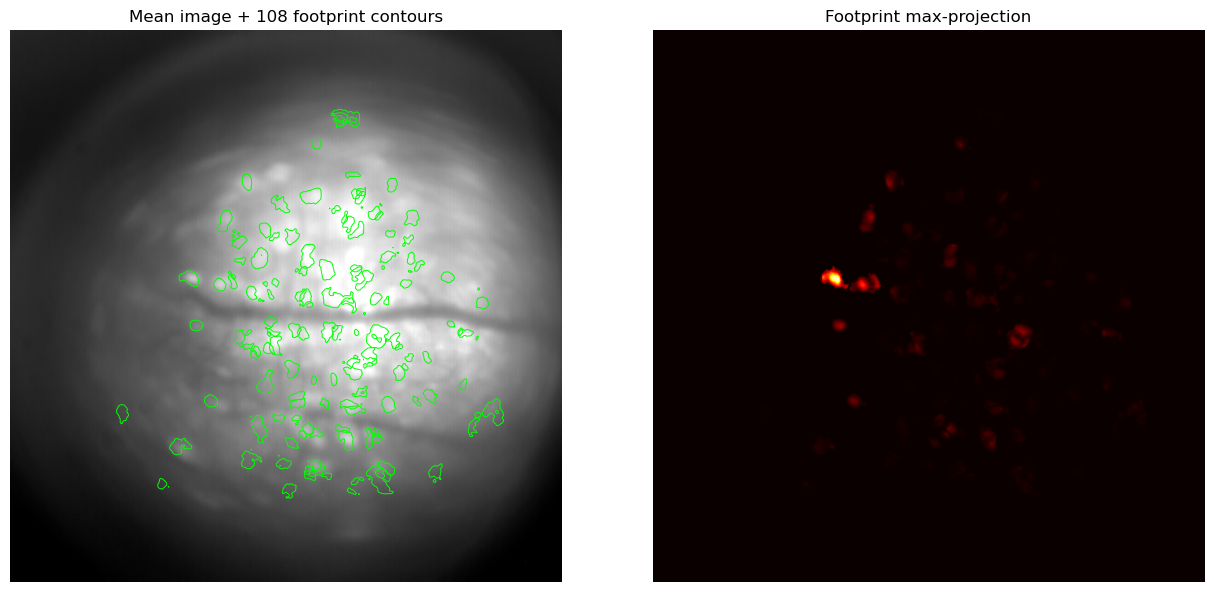

In [28]:
mean_img = movie.mean(axis=0)
A_dense = np.asarray(model.A.todense()).reshape(H, W, K)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].imshow(mean_img, cmap='gray',
               vmin=np.percentile(mean_img, 1),
               vmax=np.percentile(mean_img, 99))
for k in range(K):
    fp = A_dense[..., k]
    if fp.max() <= 0:
        continue
    axes[0].contour(fp, levels=[fp.max() * 0.3], colors='lime', linewidths=0.7)
axes[0].set_title(f'Mean image + {K} footprint contours')
axes[0].axis('off')

axes[1].imshow(A_dense.max(axis=2), cmap='hot')
axes[1].set_title('Footprint max-projection')
axes[1].axis('off')
plt.tight_layout()
plt.show()

accepted: 43/108  (flagged ghosts hidden from this plot)


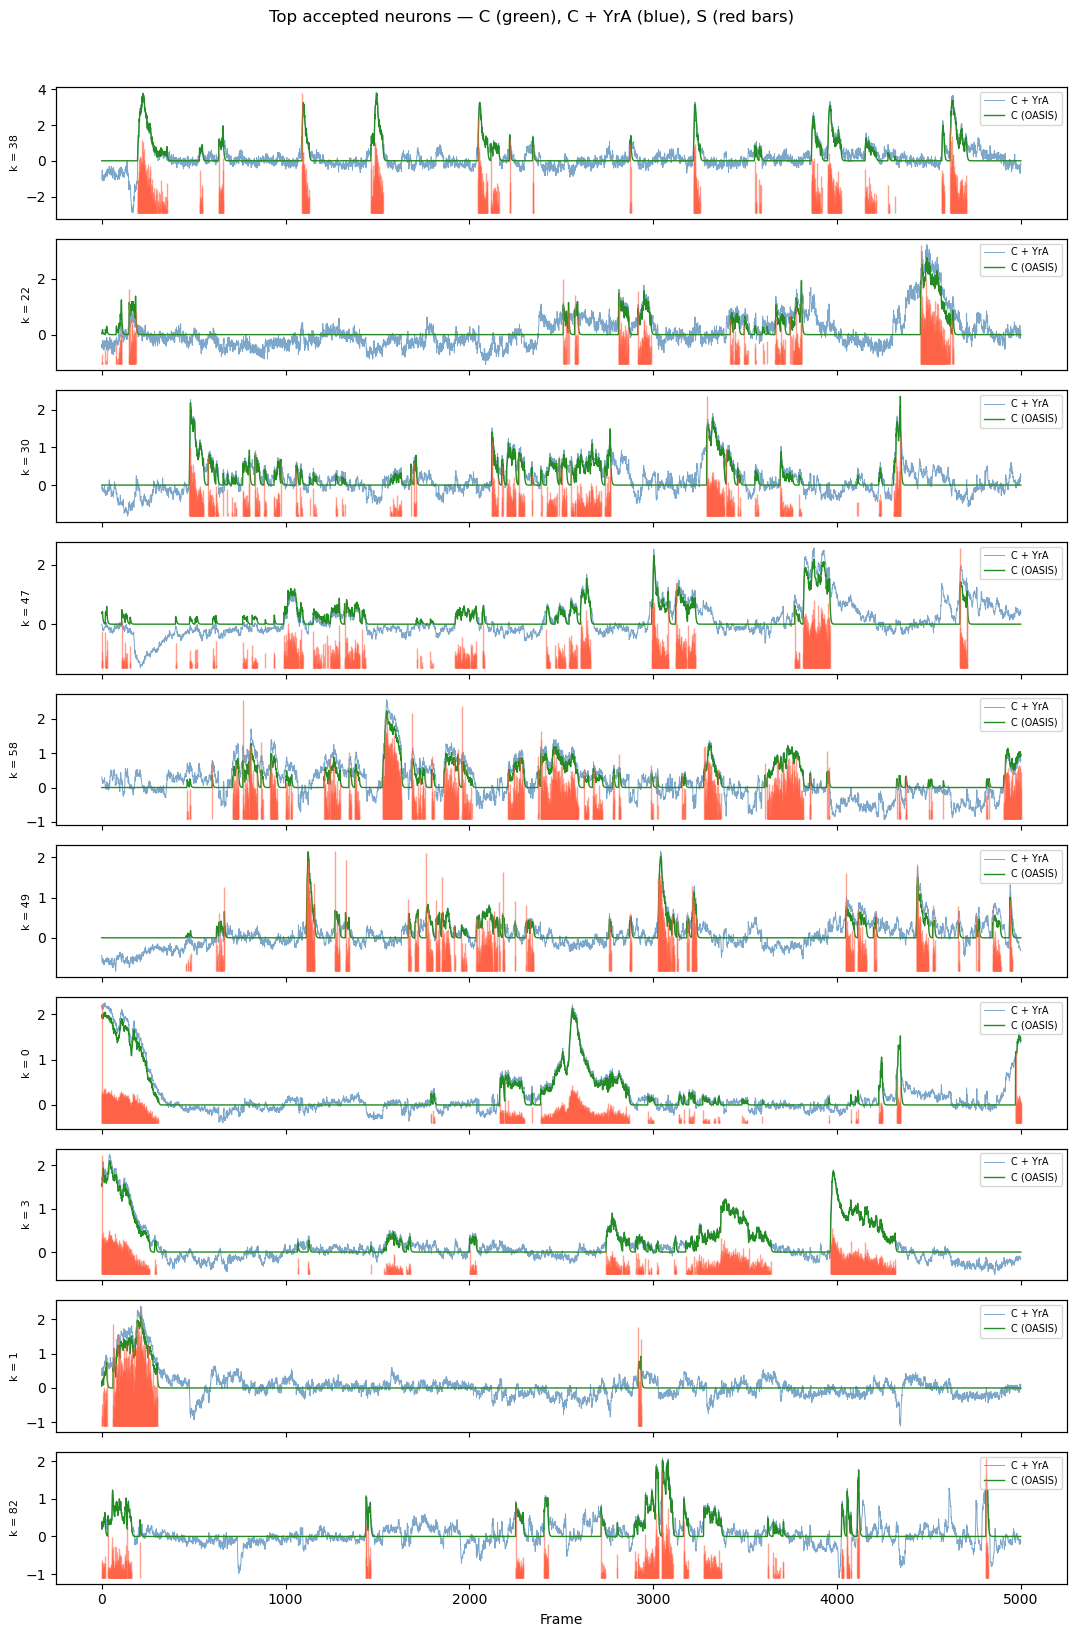

In [29]:
# Pick the N brightest *accepted* neurons (by C peak) and plot them.
# Auto-eval tags ghosts via model.accepted_mask but doesn't drop them — so
# we filter here, otherwise the "top by peak" selection happily includes
# flagged components whose C+YrA is just background drift.
N_TRACES = min(10, K)

acc_idx = np.flatnonzero(model.accepted_mask)
n_acc = acc_idx.size
print(f'accepted: {n_acc}/{K}  (flagged ghosts hidden from this plot)')

if n_acc == 0:
    print('No accepted components — nothing to plot.')
else:
    N_TRACES = min(N_TRACES, n_acc)
    peak_acc = model.C[acc_idx].max(axis=1)
    top_k = acc_idx[np.argsort(-peak_acc)[:N_TRACES]]
    C_proj = model.C_projected   # = model.C + model.YrA — shape-faithful

    fig, axes = plt.subplots(N_TRACES, 1, figsize=(11, 1.6 * N_TRACES), sharex=True)
    if N_TRACES == 1:
        axes = [axes]
    for ax, k in zip(axes, top_k):
        ax.plot(C_proj[k], lw=0.7, color='steelblue', alpha=0.7, label='C + YrA')
        ax.plot(model.C[k], lw=1.0, color='forestgreen', label='C (OASIS)')
        ax2 = ax.twinx()
        # vlines over non-zero spike times only — ax2.bar(T_frames, S[k]) creates
        # one Rectangle artist per frame, which is unusable for T >> 1000.
        nz = np.flatnonzero(model.S[k])
        if nz.size:
            ax2.vlines(nz, 0, model.S[k][nz], color='tomato',
                       alpha=0.6, linewidth=1.0, label='S')
        ax2.set_yticks([])
        ax.set_ylabel(f'k = {k}', fontsize=8)
        ax.legend(loc='upper right', fontsize=7)
    axes[-1].set_xlabel('Frame')
    plt.suptitle('Top accepted neurons — C (green), C + YrA (blue), S (red bars)', y=1.02)
    plt.tight_layout()
    plt.show()

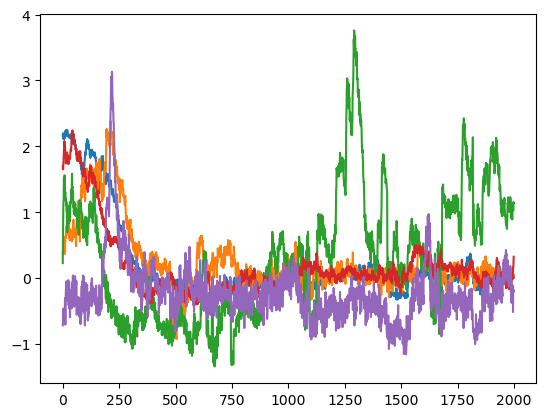

In [30]:
plt.figure()
plt.plot(model.C_projected.T[:2000,:5])

## 7. Save results to disk

`model.save(output_dir)` writes the full result set as standalone files
(same layout `full_pipeline.py` uses, so existing analysis scripts keep
working). Reload anywhere with `CNMFe.load(output_dir)`.

Files written:

- `A.npz` â€” sparse CSC footprints `(H*W, K)`
- `C.npy` â€” OASIS-deconvolved traces `(K, T)`
- `S.npy` â€” spike trains `(K, T)`
- `YrA.npy` â€” residual traces; `C + YrA` (== `model.C_projected`) = noisy projected trace
- `C_raw.npy` â€” raw init traces
- `sn.npy` â€” per-pixel noise std `(H, W)`
- `b0.npy`, `W.npz` â€” ring-background baseline + weights
- `g.npy`, `sn_per_k.npy` â€” per-component AR coefs + noise std
- `params.json` â€” the `CNMFeParams` used
- `manifest.json` â€” `dims`, `K`, `T` (non-parameter metadata)
- `shifts.npy` â€” copied from `mc_output/` if present
- `run_info.json` â€” notebook-level metadata (mc_zarr path, time_stride, wall time)

In [31]:
# model.save() writes A.npz, C.npy, S.npy, YrA.npy, sn.npy, b0.npy, W.npz,
# g.npy, sn_per_k.npy, params.json, and manifest.json.
model.save(OUTPUT_DIR)

# Carry MC shifts forward from part 1 if present; this notebook ran with
# do_motion_correction=False so model.shifts is None.
mc_shifts_src = MC_ZARR.parent / 'shifts.npy'
if mc_shifts_src.exists():
    import shutil
    shutil.copy(mc_shifts_src, OUTPUT_DIR / 'shifts.npy')

# Optional run-level metadata that isn't part of CNMFeParams.
run_info = {
    'mc_zarr': str(MC_ZARR),
    'movie_shape_loaded': list(movie.shape),
    'time_stride': TIME_STRIDE,
    'K_extracted': K,
    'wall_time_s': round(fit_elapsed, 2),
}
(OUTPUT_DIR / 'run_info.json').write_text(json.dumps(run_info, indent=2))

print(f'Results saved to {OUTPUT_DIR}/')
for p in sorted(OUTPUT_DIR.iterdir()):
    if p.is_file():
        print(f'  {p.name:18s}  {p.stat().st_size / 1e6:7.2f} MB')

print('\nReload anywhere with:')
print(f"  from minicnmfe.pipeline import CNMFe")
print(f"  model = CNMFe.load(r'{OUTPUT_DIR}')")
print(f"  C_proj = model.C_projected   # = model.C + model.YrA")

Results saved to /home/fs539/code/simpler_cnmfe/demo_movies/demo_session/mc_output/results/
  A.npz                  0.11 MB
  C.npy                  2.16 MB
  C_raw.npy              2.16 MB
  S.npy                  2.16 MB
  W.npz                191.66 MB
  YrA.npy                2.16 MB
  accepted_mask.npy      0.00 MB
  b0.npy                 1.44 MB
  eval_info.npz          0.00 MB
  g.npy                  0.00 MB
  manifest.json          0.00 MB
  params.json            0.00 MB
  run_info.json          0.00 MB
  shifts.npy             0.09 MB
  sn.npy                 1.44 MB
  sn_per_k.npy           0.00 MB

Reload anywhere with:
  from minicnmfe.pipeline import CNMFe
  model = CNMFe.load(r'/home/fs539/code/simpler_cnmfe/demo_movies/demo_session/mc_output/results')
  C_proj = model.C_projected   # = model.C + model.YrA


## 8. What's next

Reload the model in any downstream analysis script:

```python
from minicnmfe.pipeline import CNMFe

model = CNMFe.load('results/')        # restores A, C, S, YrA, sn, b0, W, g, ...
A   = model.A                          # (H*W, K) sparse footprints
C   = model.C                          # (K, T)   OASIS-deconvolved
S   = model.S                          # (K, T)   spike trains
C_proj = model.C_projected             # (K, T)   = C + YrA, shape-faithful
params = model.params                  # CNMFeParams used for the fit
```

Use `model.C` (clean AR(1)) for spike-event detection and amplitude features;
use `model.C_projected` whenever the OASIS shape constraint would distort the
answer (cross-correlation with behaviour, regression against an external
signal, raw-fluorescence plotting).

If results look off:

- **Too few neurons** â€” lower `min_corr` and/or `min_pnr`. Check the CORRÃ—PNR
  map: are bright spots being skipped?
- **Too many duplicates** â€” raise `merge_thr_corr`, lower
  `merge_centre_dist_factor`, or check that `sigma` matches the actual neuron
  size (too small `sigma` â‡’ multiple seeds per neuron).
- **Smeared / vasculature-shaped footprints** â€” raise `spatial_max_thr` so
  weak pixels are clipped.
- **Noisy / shrinking traces over iterations** â€” the AR cache should prevent
  this, but you can also try `global_ar=False` (per-neuron g) or lower
  `n_iter_main`.


## 9. Optional: streaming extraction for 60k+ frame recordings

The flow above materialises the corrected movie in RAM (`movie` is a
float32 numpy array of shape `(T, H, W)`). On a 10k × 600 × 600 movie
that is ~14 GB — fine on most workstations. For longer recordings
(60k+ frames, ~86 GB) the working set exceeds typical RAM.

The streaming alternative uses a **pixel-major** zarr alongside the
time-major `mc.zarr`:

```
mc.zarr            (T, H, W)         — time-major, used for the strided init sample
Y_flat_pixel.zarr  (H*W, T)          — pixel-major, used for extraction
```

You have two ways to enable it:

1. **Easiest (auto-derive):** pass `output_dir=` to `fit()` and skip
   `Y_flat_zarr` entirely. The pipeline creates
   `<output_dir>/Y_flat_pixel.zarr` from the input zarr on first call
   (one disk pass) and reuses it on subsequent calls (`skip_if_exists`).

2. **Manual:** call `minicnmfe.io.transpose_zarr_to_pixel_major(...)` yourself
   and pass the resulting handle as `Y_flat_zarr=...`. Useful when you
   want to control chunk layout or place the pixel-major store somewhere
   other than `output_dir`.

Both paths are parallel — `compute_W`'s per-pixel ring solve uses threaded
workers (zarr reads, `np.linalg.solve`, and `np.einsum` all release the
GIL). Peak RAM is `K·T·4` (traces) plus small per-batch buffers,
independent of `T`.

In [ ]:
# --- Drop-in replacement for cells 4-5 + 12 when extracting from 60k+ frames.
# Easiest path: pass `output_dir=` to fit(). The pipeline auto-derives
# <output_dir>/Y_flat_pixel.zarr (one-time disk transpose, idempotent on
# re-run) and streams extraction against it. Same params as cell 10 —
# n_jobs=-1 keeps every parallel step parallel, including the streaming
# ring-background solve in compute_W.

from minicnmfe.io import open_zarr

mc_3d = open_zarr(MC_ZARR)
T_full, H, W = mc_3d.shape
T = T_full   # for the params summary resolution

print(f'mc.zarr        : {mc_3d.shape}  {mc_3d.dtype}')
print(f'would materialise to ~{T_full * H * W * 4 / 1e9:.1f} GB in RAM — '
      f'streaming instead.\n')

model = CNMFe(params)
t0 = time.time()
model.fit(
    mc_3d,
    do_motion_correction=False,
    output_dir=OUTPUT_DIR,            # auto-creates Y_flat_pixel.zarr here
)
fit_elapsed = time.time() - t0

K = model.A.shape[1]
print(f'\nExtracted {K} components in {fit_elapsed:.1f}s (streaming).')
print(f'  pixel-major store: {OUTPUT_DIR / "Y_flat_pixel.zarr"}')
print(f'  Peak RAM bounded by K·T·4 (traces) + per-batch buffers, '
      f'independent of T.')

# --- Manual alternative: control chunk layout or destination ---------------
# from minicnmfe.io import transpose_zarr_to_pixel_major, open_zarr_pixel_major
# pixel_path = MC_ZARR.parent / 'mc_pixel.zarr'
# transpose_zarr_to_pixel_major(
#     MC_ZARR, pixel_path,
#     pixel_chunk=4096, time_chunk=2000,
#     src_batch_frames=2000, skip_if_exists=True,
# )
# Y_flat_zarr = open_zarr_pixel_major(pixel_path)
# model = CNMFe(params).fit(
#     mc_3d, do_motion_correction=False, Y_flat_zarr=Y_flat_zarr,
# )